# Sentiment Model Performance Analysis

This notebook loads the sampled sentence set, the model predictions, and the sentiment annotations from Dekker and Egberink, then calculates model performance on the annotated sentences.

In [18]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
if not (BASE_DIR / "annotation").exists():
    BASE_DIR = BASE_DIR.parent

STUDY_DIR = BASE_DIR  / "sentiment_model_assessment"
PREDICTIONS_PATH = STUDY_DIR / "model_predictions_wide.csv"
DB_PATH = STUDY_DIR / "databases" / "annotations.db"

PREDICTIONS_PATH, DB_PATH

(PosixPath('/Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/model_predictions_wide.csv'),
 PosixPath('/Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/databases/annotations.db'))

In [19]:
predictions = pd.read_csv(PREDICTIONS_PATH)

with sqlite3.connect(DB_PATH) as conn:
    annotations = pd.read_sql_query("SELECT * FROM annotations", conn)

predictions.shape, annotations.shape

((270, 41), (150, 5))

In [20]:
annotations = annotations.sort_values(["annotator", "sample_id", "created_at"]).drop_duplicates(
    subset=["annotator", "sample_id"], keep="last"
)

merged = predictions.merge(
    annotations[["sample_id", "annotator", "gold_sentiment", "notes", "created_at"]],
    on="sample_id",
    how="inner",
)

merged[["sample_id", "annotator", "gold_sentiment", "sentence_text"]].head()

,sample_id,annotator,gold_sentiment,sentence_text
0,e4291b9a6fafb8114777604f77925017e5d1951809f7da...,Egberink,negative,Volgens de berekeningen van verschillende advi...
1,967306248eea465b17e9023afce4241b8d6eb1423716b3...,Egberink,positive,Ook dorpen en industrieterreinen in de omgevin...
2,a1b5dbd991a9de9b251701b98ef37bd6ae098b2fcf5322...,Egberink,positive,"Het ministerie van Economische Zaken, dat de v..."
3,ccc9c8cb23873dfdc723a04b1ce161f1f67dc8cb47ce4f...,Egberink,positive,Het draagvlak voor het project is groot hier i...
4,884381e5250f52c5f8086682d3c54dc3378f0567a368de...,Egberink,neutral,"Er komt een uitspraak, tenzij MOB de bezwaren ..."


In [21]:
SENTIMENTS = ["negative", "neutral", "positive"]
MODEL_COLUMNS = [
    "robbert_v2_dutch__sentiment",
    "robbertje_dutch__sentiment",
    "nlptown_multilingual__sentiment",
    "lxyuan_distilbert_multilingual__sentiment",
    "tabularisai_multilingual__sentiment",
]

def per_class_scores(df, pred_col, gold_col="gold_sentiment", labels=SENTIMENTS):
    rows = []
    for label in labels:
        tp = int(((df[pred_col] == label) & (df[gold_col] == label)).sum())
        fp = int(((df[pred_col] == label) & (df[gold_col] != label)).sum())
        fn = int(((df[pred_col] != label) & (df[gold_col] == label)).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
        rows.append({
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": int((df[gold_col] == label).sum()),
        })
    return pd.DataFrame(rows)

def model_summary(df, pred_col, gold_col="gold_sentiment"):
    current = df.dropna(subset=[pred_col, gold_col]).copy()
    scores = per_class_scores(current, pred_col=pred_col, gold_col=gold_col)
    accuracy = float((current[pred_col] == current[gold_col]).mean()) if len(current) else 0.0
    macro_f1 = float(scores["f1"].mean()) if len(scores) else 0.0
    return {
        "n": len(current),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    }

rows = []
for annotator, group in merged.groupby("annotator"):
    for pred_col in MODEL_COLUMNS:
        summary = model_summary(group, pred_col=pred_col)
        rows.append({
            "annotator": annotator,
            "model": pred_col.replace("__sentiment", ""),
            **summary,
        })

performance = pd.DataFrame(rows).sort_values(["annotator", "accuracy"], ascending=[True, False])
performance

,annotator,model,n,accuracy,macro_f1
4,Egberink,tabularisai_multilingual,150,0.540000,0.469816
2,Egberink,nlptown_multilingual,150,0.493333,0.494016
3,Egberink,lxyuan_distilbert_multilingual,150,0.473333,0.397175
0,Egberink,robbert_v2_dutch,150,0.466667,0.388889
1,Egberink,robbertje_dutch,150,0.393333,0.327476


## Confidence-thresholded Neutral Reclassification

This section evaluates what happens when low-confidence positive/negative predictions are remapped to neutral. The analysis compares several confidence thresholds for each model and annotator.

In [27]:
CONFIDENCE_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


def apply_neutral_threshold(series_pred, series_conf, threshold):
    adjusted = series_pred.copy()
    low_confidence = series_conf < threshold
    low_confidence = low_confidence & series_pred.isin(["positive", "negative"])
    return adjusted.mask(low_confidence, "neutral")


def thresholded_summary(df, pred_col, conf_col, thresholds, gold_col="gold_sentiment"):
    current = df.dropna(subset=[pred_col, conf_col, gold_col]).copy()
    rows = []
    for threshold in thresholds:
        adjusted_pred = apply_neutral_threshold(current[pred_col], current[conf_col], threshold)
        accuracy = float((adjusted_pred == current[gold_col]).mean()) if len(current) else 0.0
        scores = per_class_scores(
            pd.DataFrame({pred_col: adjusted_pred, gold_col: current[gold_col]}),
            pred_col=pred_col,
            gold_col=gold_col,
        )
        rows.append(
            {
                "threshold": threshold,
                "n": len(current),
                "accuracy": accuracy,
                "macro_f1": float(scores["f1"].mean()) if len(scores) else 0.0,
                "negative_support": int((current[gold_col] == "negative").sum()),
                "neutral_support": int((current[gold_col] == "neutral").sum()),
                "positive_support": int((current[gold_col] == "positive").sum()),
            }
        )
    return pd.DataFrame(rows)


def build_threshold_analysis(merged_df):
    rows = []
    for annotator, group in merged_df.groupby("annotator"):
        for pred_col in MODEL_COLUMNS:
            conf_col = pred_col.replace("__sentiment", "__confidence")
            if conf_col not in group.columns:
                print(f"Skipping {pred_col} because {conf_col} is missing")
                continue
            model = pred_col.replace("__sentiment", "")
            result = thresholded_summary(group, pred_col=pred_col, conf_col=conf_col, thresholds=CONFIDENCE_THRESHOLDS)
            result["annotator"] = annotator
            result["model"] = model
            rows.append(result)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

threshold_results = build_threshold_analysis(merged)
threshold_results = threshold_results.sort_values(["annotator", "model", "threshold"], ascending=[True, True, True])

best_thresholds = (
    threshold_results.sort_values(["annotator", "model", "accuracy", "macro_f1"], ascending=[True, True, False, False])
    .groupby(["annotator", "model"], as_index=False)
    .first()
)

print("Best threshold per annotator/model:")
display(best_thresholds)

Best threshold per annotator/model:


,annotator,model,threshold,n,accuracy,macro_f1,negative_support,neutral_support,positive_support
0,Egberink,lxyuan_distilbert_multilingual,0.7,150,0.546667,0.508306,49,60,41
1,Egberink,nlptown_multilingual,0.1,150,0.493333,0.494016,49,60,41
2,Egberink,robbert_v2_dutch,0.8,150,0.553333,0.544974,49,60,41
3,Egberink,robbertje_dutch,0.8,150,0.440000,0.426313,49,60,41
4,Egberink,tabularisai_multilingual,0.1,150,0.540000,0.469816,49,60,41


## Confusion Matrix (Best Thresholds)

This section computes and plots confusion matrices using the optimized threshold for each annotator/model.

Egberink — lxyuan_distilbert_multilingual (threshold=0.7)


predicted,negative,neutral,positive
gold,,,
negative,12,37,0
neutral,1,53,6
positive,1,23,17


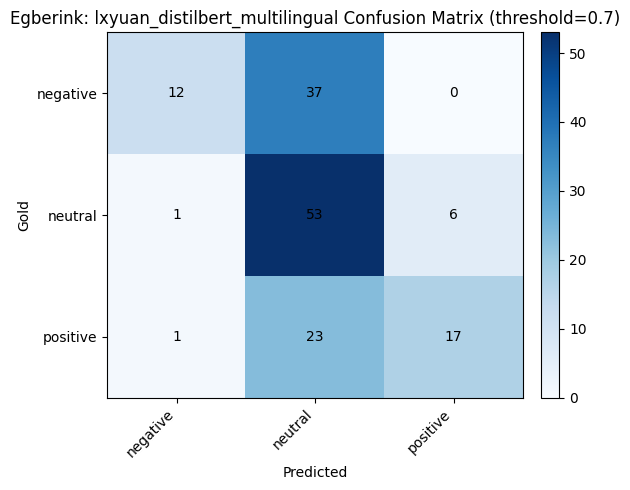

Egberink — nlptown_multilingual (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,29,15,5
neutral,11,23,26
positive,11,8,22


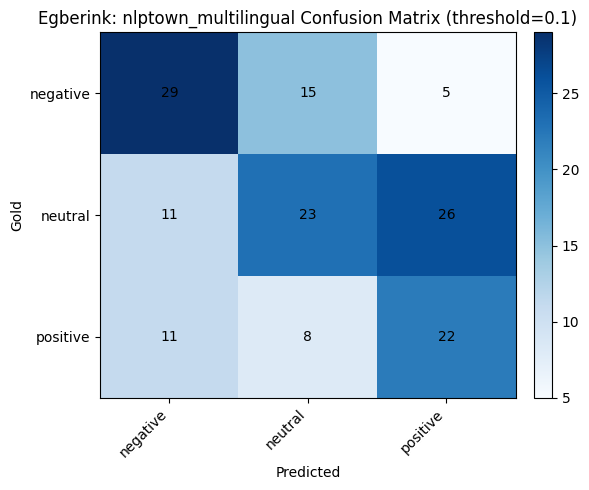

Egberink — robbert_v2_dutch (threshold=0.8)


predicted,negative,neutral,positive
gold,,,
negative,37,7,5
neutral,13,17,30
positive,6,6,29


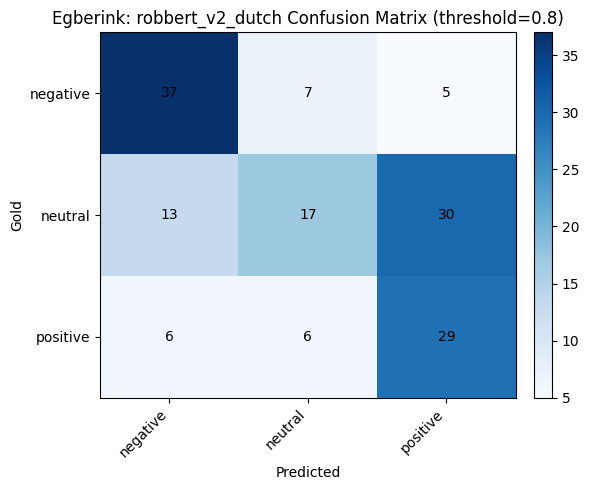

Egberink — robbertje_dutch (threshold=0.8)


predicted,negative,neutral,positive
gold,,,
negative,32,4,13
neutral,17,12,31
positive,14,5,22


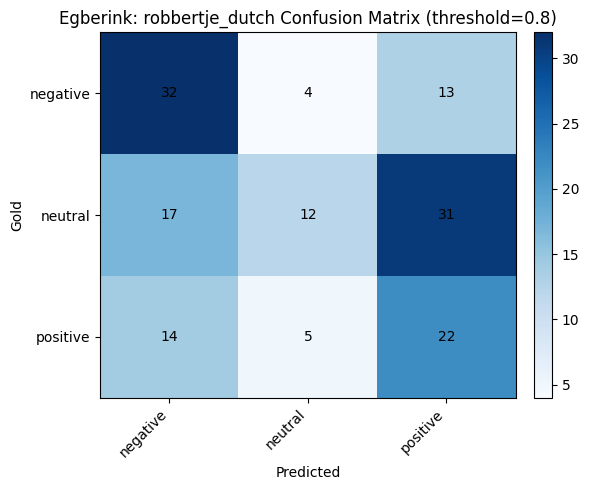

Egberink — tabularisai_multilingual (threshold=0.1)


predicted,negative,neutral,positive
gold,,,
negative,17,28,4
neutral,3,56,1
positive,4,29,8


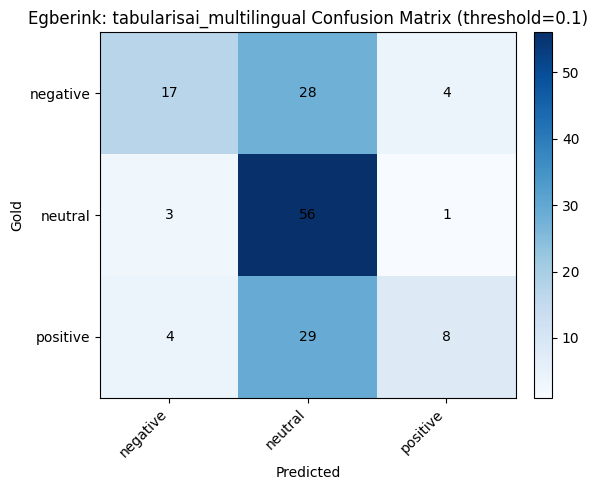

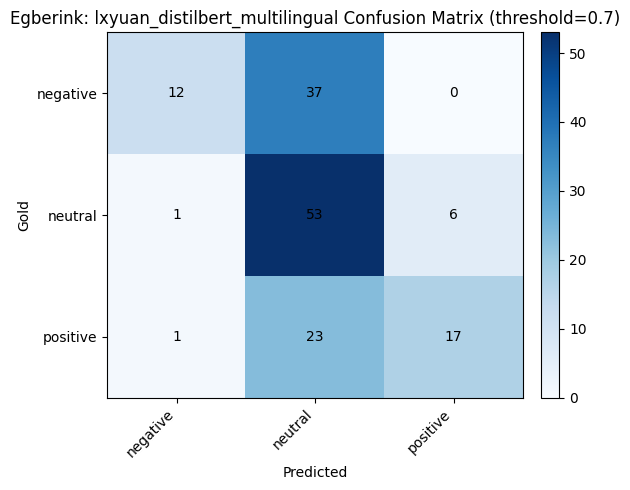

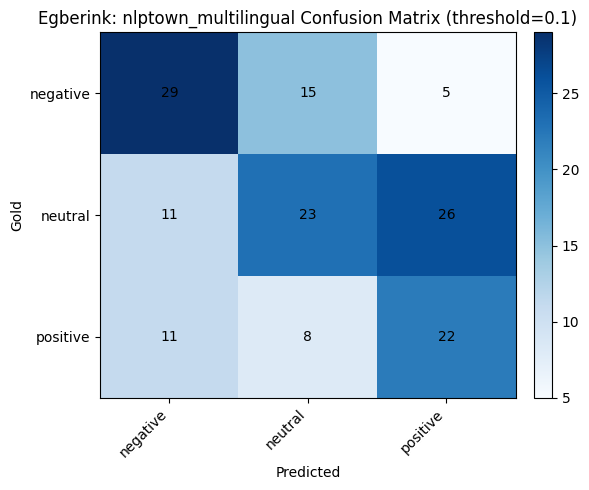

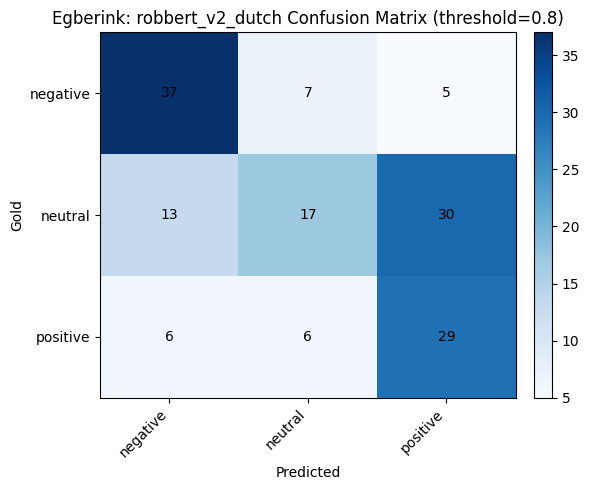

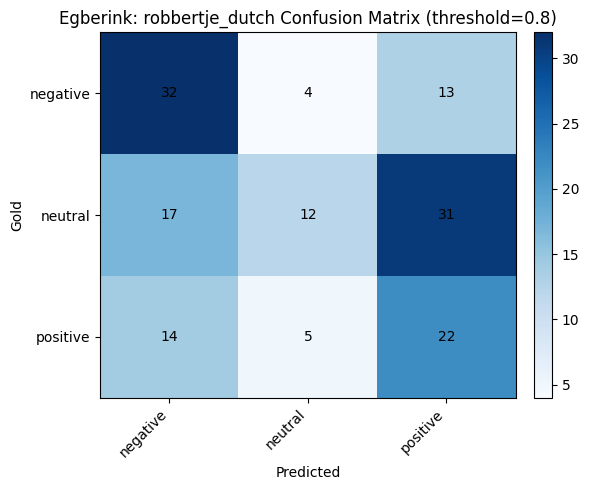

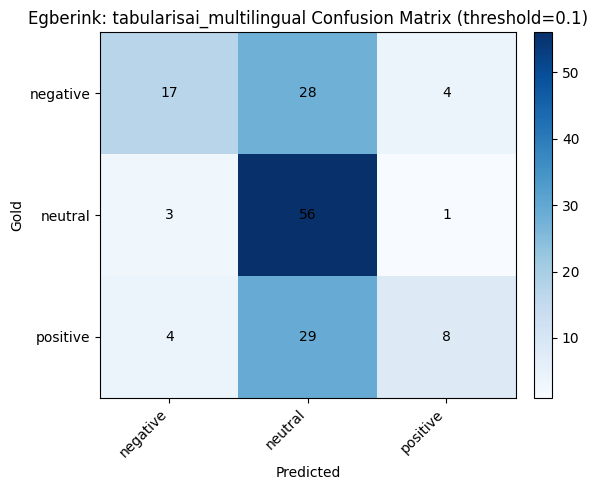

Saved thresholded confusion matrices for 5 files to /Users/Yannick/dev/geothermal_text_mining/annotation/sentiment_model_assessment/confusion_matrices


In [28]:
if best_thresholds.empty:
    raise ValueError("No best threshold values were found. Ensure the threshold analysis cell is executed first.")


def confusion_matrix_df(gold, pred, labels=SENTIMENTS):
    matrix = pd.crosstab(
        gold,
        pred,
        rownames=["gold"],
        colnames=["predicted"],
        dropna=False,
    )
    return matrix.reindex(index=labels, columns=labels, fill_value=0)


def plot_confusion_matrix(matrix, title=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix.iat[i, j]), ha="center", va="center", color="black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    if title:
        ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return fig


def adjusted_predictions(group, pred_col, conf_col, threshold):
    return apply_neutral_threshold(group[pred_col], group[conf_col], threshold)


for _, row in best_thresholds.iterrows():
    annotator = row["annotator"]
    model = row["model"]
    threshold = row["threshold"]
    pred_col = f"{model}__sentiment"
    conf_col = f"{model}__confidence"
    group = merged[merged["annotator"] == annotator].copy()
    matrix = confusion_matrix_df(
        group["gold_sentiment"],
        adjusted_predictions(group, pred_col, conf_col, threshold),
    )
    print(f"{annotator} — {model} (threshold={threshold})")
    display(matrix)
    plot_confusion_matrix(matrix, title=f"{annotator}: {model} Confusion Matrix (threshold={threshold})")

output_dir = STUDY_DIR / "confusion_matrices"
output_dir.mkdir(parents=True, exist_ok=True)

for _, row in best_thresholds.iterrows():
    annotator = row["annotator"]
    model = row["model"]
    threshold = row["threshold"]
    pred_col = f"{model}__sentiment"
    conf_col = f"{model}__confidence"
    group = merged[merged["annotator"] == annotator].copy()
    matrix = confusion_matrix_df(
        group["gold_sentiment"],
        adjusted_predictions(group, pred_col, conf_col, threshold),
    )
    csv_path = output_dir / f"{annotator}_{model}_threshold_{threshold}_confusion_matrix.csv"
    matrix.to_csv(csv_path)
    fig = plot_confusion_matrix(matrix, title=f"{annotator}: {model} Confusion Matrix (threshold={threshold})")
    png_path = output_dir / f"{annotator}_{model}_threshold_{threshold}_confusion_matrix.png"
    fig.savefig(png_path, bbox_inches="tight")
    plt.close(fig)

print(f"Saved thresholded confusion matrices for {len(best_thresholds)} files to {output_dir}")

In [23]:
overlap = merged[merged["assignment_group"] == "overlap"].copy()
overlap_gold = overlap.pivot_table(
    index="sample_id",
    columns="annotator",
    values="gold_sentiment",
    aggfunc="first",
)
overlap_gold = overlap_gold.dropna().reset_index()
overlap_gold["annotator_agree"] = overlap_gold["Dekker"] == overlap_gold["Egberink"]
overlap_gold[["sample_id", "Dekker", "Egberink", "annotator_agree"]].head()

KeyError: 'Dekker'

In [ ]:
overlap_gold["annotator_agree"].mean() if len(overlap_gold) else None

In [ ]:
performance.to_csv(STUDY_DIR / "model_performance_from_notebook.csv", index=False)
performance